# Chapter 31: Ensemble Scenarios and Sensitivity Analysis

*Part VII — Scaling, Migration & Reference*

<div class="admonition note">
<p class="admonition-title">Draft chapter</p>
<p>This chapter is an early draft of the ensemble-and-sensitivity-analysis workflow, not a settled final version — expect it to evolve. The ensemble example itself, built on Chapter 23's <code>PredatorPrey</code> model, was tested end to end, including the Sobol sampling and analysis pipeline (8,192 runs, about 30 seconds); what's likely to change is scope and framing as this topic develops alongside the rest of the book.</p>
</div>

## Learning Objectives

By the end of this chapter you will be able to:

- Explain why a single deterministic model run is rarely enough to trust a result
- Design and run a parameter ensemble
- Compute first-order and total Sobol indices with `SALib`, and read what each one means
- Choose a sample size and an output of interest that make those indices trustworthy
- Interpret an ensemble's spread as a statement about uncertainty, not a single "correct" answer

In [1]:
# Standard imports
import contextlib
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Every model this book has run so far — Chapter 23's `PredatorPrey`, Chapter 24's `FireModel`, Chapter 26's eventual LUCC executors — has run exactly once, with one fixed set of parameters, producing one deterministic answer. That answer is only as trustworthy as the parameter values feeding it, and in a real project those values are rarely known exactly — a growth rate estimated from noisy field data, a mortality rate borrowed from a different study system entirely. This chapter is about turning "here's what the model says with these parameters" into "here's what the model says across the plausible range of parameters, and here's which of those parameters actually matters."

## Introduction to Ensemble Modeling

An **ensemble** is simply many runs of the same model, each with a different parameter combination, treated as one collective result rather than many separate ones. The reason to build one at all is that a single run answers the wrong question — "what does the model predict" is less useful, on its own, than "how much does the model's prediction change as the inputs vary within their plausible range." A tight ensemble (every run lands close together) says the model's conclusion is robust to what you don't know precisely about the parameters; a wide, divergent ensemble says the opposite — and that distinction is invisible from any single run, however carefully chosen.

## Designing an Ensemble: Parameter Sampling

The naive approach — loop over every combination of a handful of values per parameter — scales catastrophically: 3 parameters at 10 values each is already 1,000 runs, and every parameter added multiplies the total again. **Quasi-random sampling** (Sobol sequences, used below) instead spreads a fixed sampling *budget* evenly across the whole parameter space, covering it far more uniformly than either a full grid or genuinely random points would for the same number of runs — the property Sobol *analysis* specifically needs to work correctly, not an incidental convenience.

`SALib`'s `sobol.sample()` needs a `problem` definition — parameter names and their bounds — and returns exactly the array of parameter combinations a Sobol sensitivity analysis requires:

In [2]:
from SALib.sample import sobol as sobol_sample

problem = {
    "num_vars": 3,
    "names": ["prey_growth", "prey_death_pred", "pred_death"],
    "bounds": [
        [0.05, 0.15],    # prey_growth
        [0.0005, 0.002], # prey_death_pred
        [0.01, 0.05],    # pred_death
    ],
}

param_values = sobol_sample.sample(problem, N=1024, seed=42)  # seed: the same design every run
print("Parameter combinations generated:", param_values.shape[0])
print("First 3 rows:")
print(param_values[:3])

Parameter combinations generated: 8192
First 3 rows:
[[0.09310295 0.00172155 0.04225651]
 [0.05534567 0.00172155 0.04225651]
 [0.09310295 0.00094691 0.04225651]]


`N=1024` is a base sample size, not the run count: to separate each parameter's own effect from its interactions, Saltelli's scheme evaluates the model N × (2D + 2) times for D parameters — here 1024 × 8 = 8,192 runs. That sounds like a lot, but a Lotka-Volterra run costs a few milliseconds, so the whole ensemble takes about half a minute. *How Big Does N Need to Be?*, further down, shows what goes wrong with a smaller budget.

## Running an Ensemble

Reusing Chapter 23's `PredatorPrey` unchanged, one run per sampled parameter combination. Two outputs are worth keeping from every run, because they ask different questions: the prey population at the **last tick**, and the prey population **averaged over the whole run**. `PredatorPrey` only keeps its current state, so a tiny `Recorder` model, registered in the same `Environment` right after it, stores the prey value every tick — `Environment` runs models in the order they were constructed, so the recorder always sees the value `PredatorPrey` has just computed. The runs last 1,000 ticks, several full predator-prey cycles for every parameter combination sampled here.

In [3]:
from dissmodel.core import Environment, Model
from dissmodel_sysdyn.models import PredatorPrey


class Recorder(Model):
    """Store one attribute of another model at every tick."""
    def setup(self, target, attr):
        self.target, self.attr, self.history = target, attr, []

    def execute(self):
        self.history.append(getattr(self.target, self.attr))


def run_predator_prey(prey_growth, prey_death_pred, pred_death):
    with contextlib.redirect_stdout(io.StringIO()):  # silence Environment's per-run log
        env = Environment(start_time=0, end_time=1000)
        pp = PredatorPrey(
            predator=40.0, prey=1000.0,
            prey_growth=prey_growth, prey_death_pred=prey_death_pred,
            pred_death=pred_death, pred_growth_kills=0.00002,
        )
        rec = Recorder(target=pp, attr="prey")
        env.run()
    return pp.prey, np.mean(rec.history)  # final prey, time-averaged prey


results = np.array([run_predator_prey(*row) for row in param_values])
final_prey, mean_prey = results[:, 0], results[:, 1]
print(f"Ran {len(results)} simulations")
print(f"Final prey:    min={final_prey.min():.1f}, median={np.median(final_prey):.1f}, max={final_prey.max():.1f}")
print(f"Mean prey:     min={mean_prey.min():.1f}, median={np.median(mean_prey):.1f}, max={mean_prey.max():.1f}")

Ran 8192 simulations
Final prey:    min=0.0, median=965.3, max=15225.5
Mean prey:     min=476.0, median=1547.3, max=2718.2


## Interpreting Ensemble Output

A histogram of the ensemble's output is the first thing worth looking at — not the mean alone, which can hide a distribution that's actually bimodal or wildly skewed:

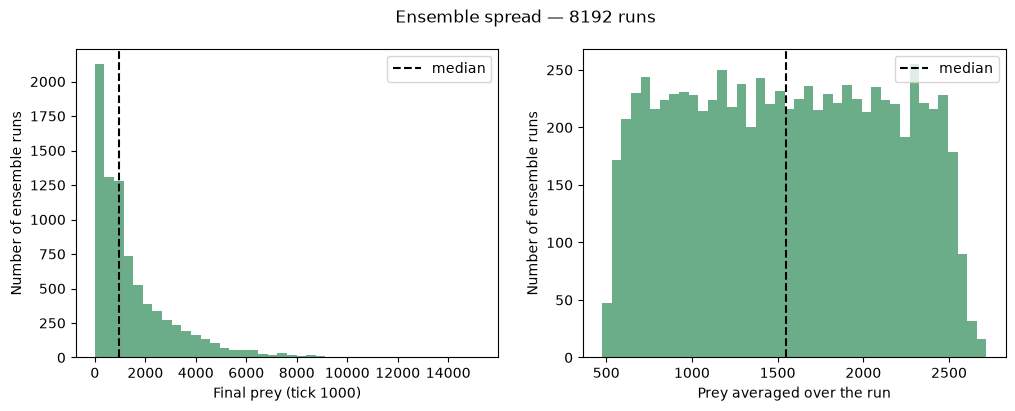

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, values, label in zip(axes, [final_prey, mean_prey], ["Final prey (tick 1000)", "Prey averaged over the run"]):
    ax.hist(values, bins=40, color="seagreen", alpha=0.7)
    ax.axvline(np.median(values), color="black", linestyle="--", label="median")
    ax.set_xlabel(label)
    ax.set_ylabel("Number of ensemble runs")
    ax.legend()
fig.suptitle(f"Ensemble spread — {len(results)} runs")
plt.show()

The two histograms describe the same 8,192 runs and still look nothing alike. The final prey population is spread from zero to more than 15,000, heavily skewed: where each run happens to be in its cycle at tick 1,000 depends on every parameter at once. The time-averaged population is far more orderly. Reporting only "the model predicts X prey" would hide both facts — how much the answer depends on parameters we don't know precisely, and how much it depends on *which* question we asked.

## Global Sensitivity Analysis: Sobol Indices

A wide ensemble spread raises the obvious next question: spread caused by *which* parameter? `SALib`'s Sobol analysis decomposes the output variance into shares. The **first-order index** `S1` is the share a parameter explains *on its own*; the **total index** `ST` adds every interaction that parameter takes part in. `ST − S1` is therefore the part of a parameter's influence that only exists in combination with the others — which is why both are reported below, for both outputs:

In [5]:
from SALib.analyze import sobol as sobol_analyze

rows = []
for output_name, Y in [("final prey", final_prey), ("mean prey", mean_prey)]:
    Si = sobol_analyze.analyze(problem, Y, seed=42)
    for i, name in enumerate(problem["names"]):
        rows.append({"output": output_name, "parameter": name,
                     "S1": Si["S1"][i], "S1_conf": Si["S1_conf"][i],
                     "ST": Si["ST"][i], "ST_conf": Si["ST_conf"][i]})

sensitivity = pd.DataFrame(rows).round(2)
sensitivity

,output,parameter,S1,S1_conf,ST,ST_conf
0,final prey,prey_growth,0.04,0.06,0.67,0.10
1,final prey,prey_death_pred,0.03,0.11,0.88,0.14
2,final prey,pred_death,0.14,0.08,0.82,0.12
3,mean prey,prey_growth,0.00,0.01,0.00,0.00
4,mean prey,prey_death_pred,0.00,0.01,0.00,0.00
5,mean prey,pred_death,1.00,0.06,1.00,0.06


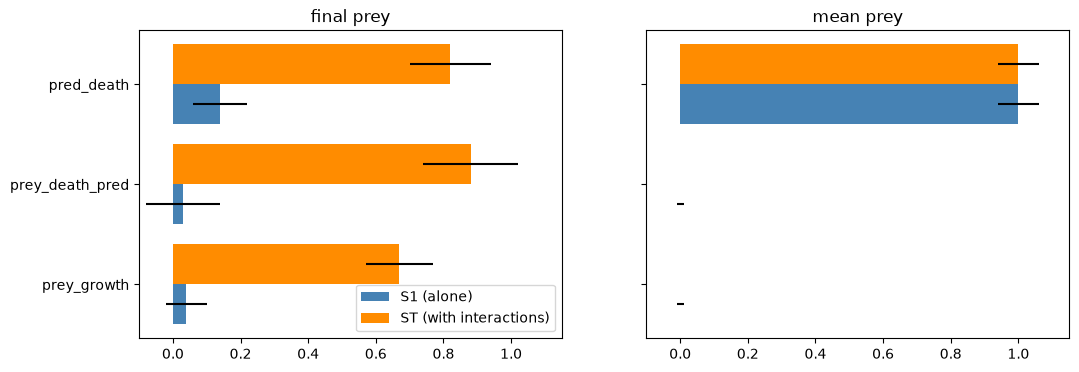

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
y = np.arange(len(problem["names"]))
for ax, output_name in zip(axes, ["final prey", "mean prey"]):
    part = sensitivity[sensitivity["output"] == output_name]
    ax.barh(y - 0.2, part["S1"], height=0.4, xerr=part["S1_conf"], label="S1 (alone)", color="steelblue")
    ax.barh(y + 0.2, part["ST"], height=0.4, xerr=part["ST_conf"], label="ST (with interactions)", color="darkorange")
    ax.set_yticks(y, problem["names"])
    ax.set_xlim(-0.1, 1.15)
    ax.set_title(output_name)
axes[0].legend(loc="lower right")
plt.show()

An `S1` of 0 means a parameter, varied alone, explains none of the output variance; an `S1` near 1 means it explains nearly all of it. The two outputs give opposite pictures:

- **Final prey.** Every `S1` is small (0.14 at most), yet every `ST` is large (0.67 to 0.88). No parameter matters on its own; all of them matter together. That is what a snapshot of an oscillating system looks like: the value at tick 1,000 depends on the *phase* of the cycle, and the phase depends on all three rates at once. A one-parameter-at-a-time sweep would have called all three parameters unimportant.
- **Mean prey.** `pred_death` explains essentially all of the variance (`S1` ≈ `ST` ≈ 1) and the other two nothing. This is not a coincidence of the sample — it is Lotka-Volterra theory showing through. Averaged over whole cycles, the prey population sits at its equilibrium, `pred_death / pred_growth_kills` (Chapter 23), which contains no other parameter. The ensemble rediscovered, numerically, a result you could have derived on paper.

That second case is the best test a sensitivity analysis can pass: where theory gives the answer, the method recovers it.

## How Big Does N Need to Be?

Sobol indices are Monte Carlo estimates, and their confidence intervals shrink only with the square root of the budget. It is worth seeing what an under-sized ensemble reports. The cell below repeats the whole pipeline with `N=32` — 256 runs:

In [7]:
small_design = sobol_sample.sample(problem, N=32, seed=42)
small = np.array([run_predator_prey(*row) for row in small_design])
for output_name, Y in [("final prey", small[:, 0]), ("mean prey", small[:, 1])]:
    Si = sobol_analyze.analyze(problem, Y, seed=42)
    print(f"{output_name:10s}  S1 = {np.round(Si['S1'], 2)}  ± {np.round(Si['S1_conf'], 2)}")

final prey  S1 = [ 1.01 -0.06  0.11]  ± [0.82 0.47 0.37]
mean prey   S1 = [ 0.   -0.03  0.83]  ± [0.03 0.03 0.38]


With 256 runs the final-prey `S1` for `prey_growth` comes out near 1 — the opposite of the 8,192-run answer — with a confidence interval nearly as wide as the estimate itself. Anyone reading that table without the intervals would rank `prey_growth` first and recommend spending research effort on it. The mean-prey result is steadier, because that output depends on one parameter almost linearly, but its interval is still six times wider than at `N=1024`.

The practical rule: report the confidence intervals next to every index, and increase `N` until the ranking you intend to act on no longer changes and the intervals no longer overlap. For a model this cheap, there is no reason to stop earlier.

## Interpreting GSA for Policy

A parameter with a high index is where reducing uncertainty pays off most: narrowing its plausible range — better field data, a more targeted study — shrinks the ensemble's spread more than narrowing any other. The analysis above adds two conditions to that sentence.

First, **the answer belongs to the question**. If the quantity that matters is the long-run average prey population, the recommendation is unambiguous: measure predator mortality better, and don't spend effort on the other two rates. If the quantity that matters is the population at a specific future date, no single parameter carries the uncertainty, and refining any one of them alone will barely narrow the forecast.

Second, **the answer belongs to the ranges**. Indices are relative to the bounds in `problem`: widen one parameter's range and its share grows. The bounds are part of the result and should be reported with it.

Stated with both conditions — "for the long-run mean, within these ranges, further precision on predator mortality matters more than anything else" — a GSA result becomes a direct, defensible answer to where the next unit of research effort should go.

## Exercises

1. **A different output.** Track the final and time-averaged *predator* population instead of prey (add a second `Recorder`). Which parameter drives the predator's long-run mean? Check your answer against the predator equilibrium from Chapter 23.
2. **Find the stable N.** Rerun the pipeline with `N` = 64, 128, 256 and 512. At which `N` does the final-prey ranking stop changing, and how wide are the `ST` intervals at that point?
3. **A fourth parameter.** Add `pred_growth_kills` to `problem` (try `[0.00001, 0.00004]`). The mean-prey theory says it should now share the influence with `pred_death`. Does the ensemble agree — and is the new `ST − S1` gap large or small?
4. **From index to recommendation.** Using your own results, write two sentences in the style of *Interpreting GSA for Policy*, each naming the output and the parameter ranges it applies to.

In [8]:
# Your code here

## Summary

### Key concepts introduced

- Why a single deterministic run under-reports what a model actually knows: it hides how much the answer would change under different, equally plausible parameter values
- Quasi-random (Sobol) sampling, spreading a fixed run budget evenly across parameter space — a requirement of Sobol *analysis*, not an incidental choice
- Building an ensemble by reusing an existing model (Chapter 23's `PredatorPrey`) completely unchanged, varying only the driving loop around it
- Reading an ensemble's output distribution — spread, not just a mean — as the honest summary of a result
- First-order (`S1`) and total (`ST`) Sobol indices: what a parameter explains alone versus with its interactions — and why a snapshot of an oscillating system is almost pure interaction
- Choosing the output of interest: the time-averaged prey population recovered Lotka-Volterra theory (only `pred_death` matters), while the final snapshot did not single out any parameter
- Sample size as part of the result: with 256 runs the ranking was wrong, with 8,192 it was stable — always report confidence intervals
- Turning a sensitivity ranking into an actionable research-effort recommendation, not just a ranked list of numbers

This closes the paradigm-and-analysis arc of this book. Chapter 32 turns outward — a concept-by-concept guide for migrating an existing TerraME or LUCCME model into the ecosystem this book has spent thirty-one chapters building.

## Further Reading

- Saltelli, A. et al. (2008). *Global Sensitivity Analysis: The Primer*. Wiley — the standard reference behind Sobol indices and the sampling scheme this chapter uses
- SALib documentation: <https://salib.readthedocs.io/>
- Sobol, I. M. (2001). "Global sensitivity indices for nonlinear mathematical models and their Monte Carlo estimates." *Mathematics and Computers in Simulation*, 55(1-3), 271-280
- Saltelli, A. et al. (2010). "Variance based sensitivity analysis of model output. Design and estimator for the total sensitivity index." *Computer Physics Communications*, 181(2), 259-270